In [ ]:
!pip install ijson==3.2.1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import ijson
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import logging
from glob import glob

In [ ]:
luo_imu_sensor_locations = ['Pelvis', 'RightForeArm', 'RightUpperLeg', 'RightLowerLeg', 'LeftUpperLeg', 'LeftLowerLeg']

lower_body_imu_sensor_locations = ['Pelvis', 'RightUpperLeg', 'LeftUpperLeg', 'RightLowerLeg', 'LeftLowerLeg', 'RightFoot', 'LeftFoot']

insole_sensor_locations = ['Arch', 'Hallux', 'Heel_L', 'Heel_R', 'Met1', 'Met3', 'Met5', 'Toes']

participant_num = [1, 2, 3, 4, 5, 7, 8, 10, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25]

In [ ]:
# import csv
imu_df = pd.read_csv('/content/drive/MyDrive/Next_Step/Honda: multi_modal_gait_database/merged/base_df_imu_df.csv')

In [ ]:
imu_df.columns

Index(['time', 'participant_id', 'task', 'walk_mode',
       'insoles_RightFoot_is_step', 'insoles_RightFoot_is_lifted',
       'insoles_LeftFoot_is_step', 'insoles_LeftFoot_is_lifted',
       'sensor_location', 'orientation_qi', 'orientation_qj', 'orientation_qk',
       'position_x', 'position_y', 'position_z', 'velocity_x', 'velocity_y',
       'velocity_z', 'acceleration_x', 'acceleration_y', 'acceleration_z',
       'angularVelocity_x', 'angularVelocity_y', 'angularVelocity_z',
       'angularAcceleration_x', 'angularAcceleration_y',
       'angularAcceleration_z', 'sensorFreeAcceleration_x',
       'sensorFreeAcceleration_y', 'sensorFreeAcceleration_z',
       'sensorMagneticField_x', 'sensorMagneticField_y',
       'sensorMagneticField_z', 'sensorOrientation_qi', 'sensorOrientation_qj',
       'sensorOrientation_qk'],
      dtype='object')

In [ ]:
imu_df = imu_df[['time', 'participant_id', 'task', 'walk_mode',
                 'sensor_location', 'acceleration_x', 'acceleration_y', 'acceleration_z',
                 'angularVelocity_x', 'angularVelocity_y', 'angularVelocity_z']]

In [ ]:
imu_df['walk_mode'] = imu_df['walk_mode'].replace({'pavement_up': 'stairs_up', 'pavement_down': 'stairs_down'})

In [ ]:
# show all the rows in the df
pd.set_option('display.max_rows', None)

In [ ]:
imu_df['participant_id'].value_counts()

,count
participant_id,
12,676668
18,675336
23,666462
24,652110
25,644796
14,639690
10,636552
16,636222
8,627138


In [ ]:
import random
import numpy as np
import pandas as pd

def extract_and_sample_segments(data, segment_size=85, target_segments=None, random_seed=42, overlap=0.5):
    random.seed(random_seed)
    all_segments = {}

    # Convert segment_size to the number of unique time steps
    segment_size = int(segment_size)
    step_size = int(segment_size * (1 - overlap))

    for participant_id, participant_df in data.groupby('participant_id'):
        for surface_type, surface_df in participant_df.groupby('walk_mode'):

            # Ensure data is sorted by time
            surface_df = surface_df.sort_values(['task', 'time']).reset_index(drop=True)

            # Precompute the number of unique sensors per time value for efficient lookup
            sensor_counts_per_time = surface_df.groupby('time')['sensor_location'].nunique()

            # Identify potential start indices for valid segments
            valid_time_indices = []
            for start_idx in range(0, len(surface_df) - segment_size + 1, step_size):
                segment_times = surface_df['time'].iloc[start_idx:start_idx + segment_size].unique()

                # Check if all unique times in the segment have exactly 6 sensors
                if all(sensor_counts_per_time.loc[segment_time] == 6 for segment_time in segment_times):
                    valid_time_indices.append(start_idx)

            # Extract valid segments based on start indices
            current_surface = []
            for start_idx in valid_time_indices:
                segment = surface_df.iloc[start_idx:start_idx + segment_size]
                current_surface.append(segment)

            if current_surface:
                # Store segments under participant_id and surface_type
                if participant_id not in all_segments:
                    all_segments[participant_id] = {}
                all_segments[participant_id][surface_type] = current_surface

    # Randomly sample if a target count is provided
    if target_segments is not None:
        for participant_id in all_segments:
            for surface_type in all_segments[participant_id]:
                if len(all_segments[participant_id][surface_type]) > target_segments:
                    all_segments[participant_id][surface_type] = random.sample(
                        all_segments[participant_id][surface_type], target_segments
                    )

    return all_segments


In [ ]:
# Extract segments with 50% overlap and segment size of 85
all_segments = extract_and_sample_segments(
    imu_df,
    segment_size=85,
    target_segments=100,
    overlap=0.5
)


In [ ]:
all_segments.keys()

dict_keys([1, 2, 3, 4, 5, 7, 8, 10, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25])

In [ ]:
all_segments[4]['walk'][10].head()

,time,participant_id,task,walk_mode,insoles_RightFoot_is_step,insoles_RightFoot_is_lifted,insoles_LeftFoot_is_step,insoles_LeftFoot_is_lifted,sensor_location,orientation_qi,...,angularAcceleration_z,sensorFreeAcceleration_x,sensorFreeAcceleration_y,sensorFreeAcceleration_z,sensorMagneticField_x,sensorMagneticField_y,sensorMagneticField_z,sensorOrientation_qi,sensorOrientation_qj,sensorOrientation_qk
270564,223067,4,C,walk,False,False,False,False,LeftLowerLeg,-0.460792,...,-3.915680,-1.516679,-3.320696,1.014483,0.705811,0.173584,0.597168,0.941808,-0.139852,-0.295533
270565,223067,4,C,walk,False,False,False,False,LeftUpperLeg,0.042967,...,-33.756130,3.924396,-7.236754,3.302138,0.640381,0.227539,0.615234,0.535703,0.591196,-0.437088
270566,223067,4,C,walk,False,False,False,False,Pelvis,-0.069896,...,2.629951,-0.647602,0.297067,1.090312,0.664307,-0.187744,0.037598,0.147644,0.554947,-0.073858
270567,223067,4,C,walk,False,False,False,False,RightForeArm,-0.114977,...,-4.552278,-3.621229,-3.355075,1.832387,0.638916,0.178223,-0.598145,-0.582931,0.190752,0.694724
270568,223067,4,C,walk,False,False,False,False,RightLowerLeg,-0.059845,...,0.394814,2.157624,0.062918,0.851231,0.847412,-0.097168,-0.275635,-0.668834,0.344156,0.656512


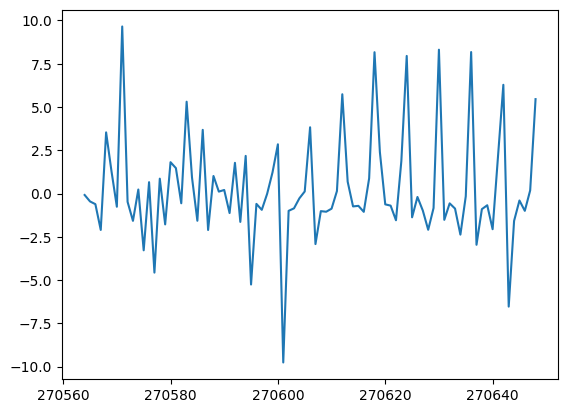

In [ ]:
plt.plot(all_segments[4]['walk'][10]['acceleration_x'])

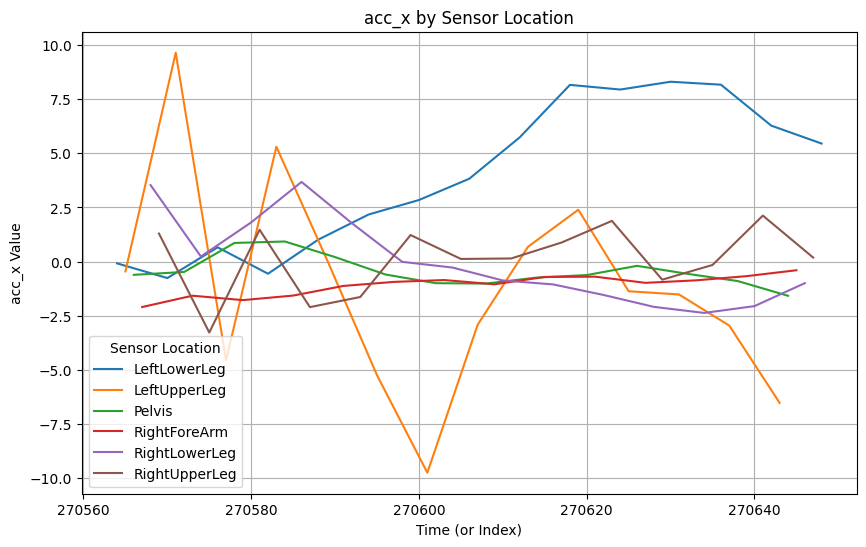

In [ ]:
import matplotlib.pyplot as plt

# Assuming `all_segments['walk'][10]` is a DataFrame and has 'Left_norm' and 'sensor_location' columns.
segment_data = all_segments[4]['walk'][10]

# Get unique sensor locations for assigning colors
sensor_locations = segment_data['sensor_location'].unique()
colors = plt.cm.tab10(range(len(sensor_locations)))  # Choose a colormap (e.g., tab10)

# Plot each sensor location in a different color
plt.figure(figsize=(10, 6))
for sensor, color in zip(sensor_locations, colors):
    # Filter data for the current sensor location
    sensor_data = segment_data[segment_data['sensor_location'] == sensor]

    # Plot the data
    plt.plot(sensor_data.index, sensor_data['acceleration_x'], label=sensor, color=color)

plt.title('acc_x by Sensor Location')
plt.xlabel('Time (or Index)')
plt.ylabel('acc_x Value')
plt.legend(title='Sensor Location')
plt.grid(True)
plt.show()


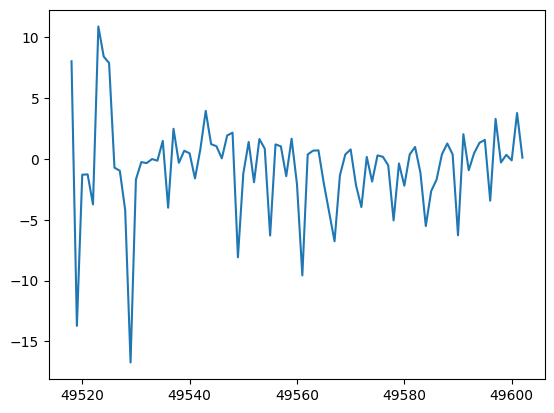

In [ ]:
plt.plot(all_segments[4]['slope_up'][17]['acceleration_x'])

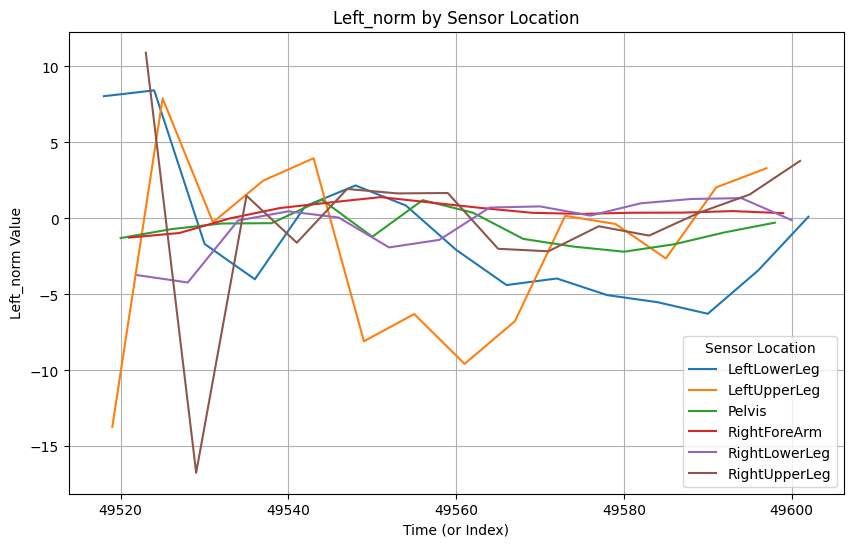

In [ ]:
import matplotlib.pyplot as plt

# Assuming `all_segments['walk'][10]` is a DataFrame and has 'Left_norm' and 'sensor_location' columns.
segment_data = all_segments[4]['slope_up'][17]

# Get unique sensor locations for assigning colors
sensor_locations = segment_data['sensor_location'].unique()
colors = plt.cm.tab10(range(len(sensor_locations)))  # Choose a colormap (e.g., tab10)

# Plot each sensor location in a different color
plt.figure(figsize=(10, 6))
for sensor, color in zip(sensor_locations, colors):
    # Filter data for the current sensor location
    sensor_data = segment_data[segment_data['sensor_location'] == sensor]

    # Plot the data
    plt.plot(sensor_data.index, sensor_data['acceleration_x'], label=sensor, color=color)

plt.title('Left_norm by Sensor Location')
plt.xlabel('Time (or Index)')
plt.ylabel('Left_norm Value')
plt.legend(title='Sensor Location')
plt.grid(True)
plt.show()


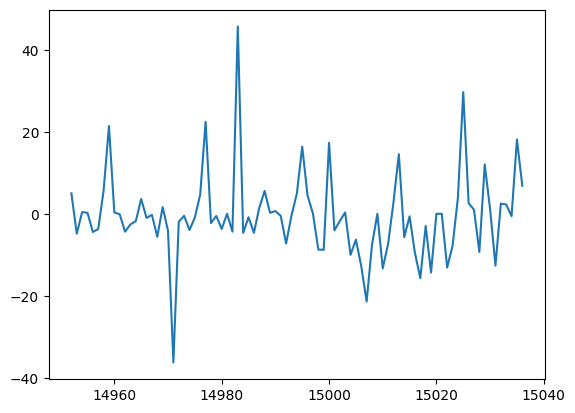

In [ ]:
plt.plot(all_segments[4]['walk'][17]['acceleration_x'])

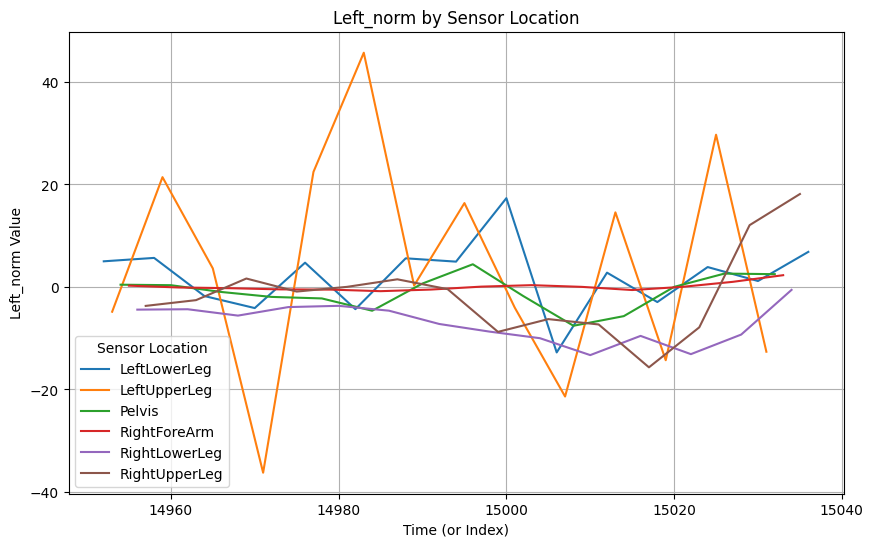

In [ ]:
import matplotlib.pyplot as plt

# Assuming `all_segments['walk'][10]` is a DataFrame and has 'Left_norm' and 'sensor_location' columns.
segment_data = all_segments[4]['walk'][17]

# Get unique sensor locations for assigning colors
sensor_locations = segment_data['sensor_location'].unique()
colors = plt.cm.tab10(range(len(sensor_locations)))  # Choose a colormap (e.g., tab10)

# Plot each sensor location in a different color
plt.figure(figsize=(10, 6))
for sensor, color in zip(sensor_locations, colors):
    # Filter data for the current sensor location
    sensor_data = segment_data[segment_data['sensor_location'] == sensor]

    # Plot the data
    plt.plot(sensor_data.index, sensor_data['acceleration_x'], label=sensor, color=color)

plt.title('Left_norm by Sensor Location')
plt.xlabel('Time (or Index)')
plt.ylabel('Left_norm Value')
plt.legend(title='Sensor Location')
plt.grid(True)
plt.show()


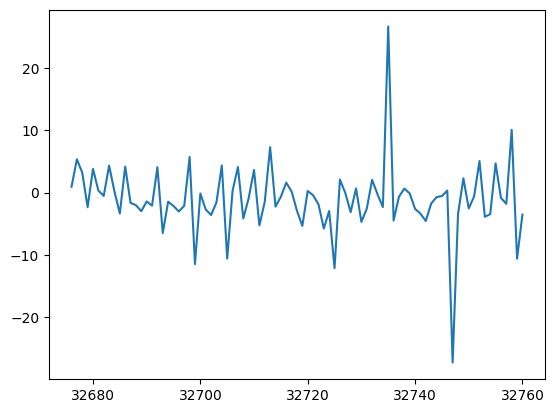

In [ ]:
plt.plot(all_segments[4]['slope_up'][0]['acceleration_x'])

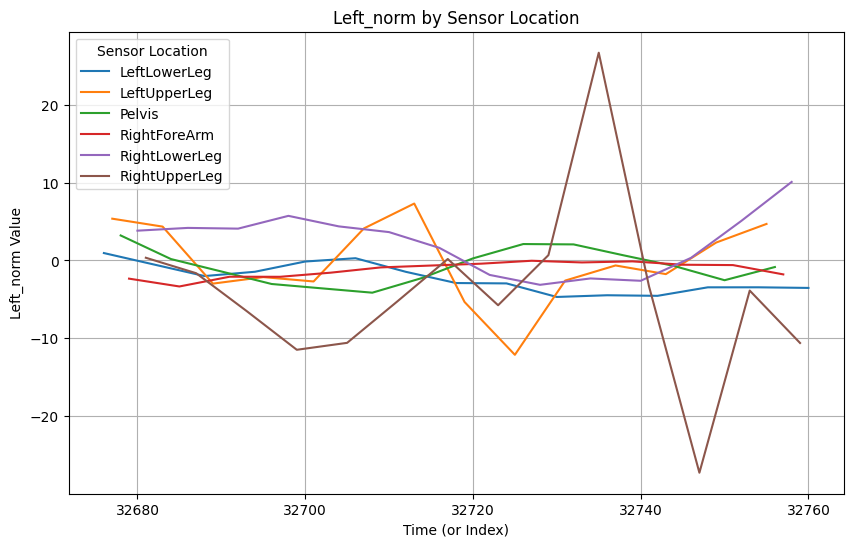

In [ ]:
import matplotlib.pyplot as plt

# Assuming `all_segments['walk'][10]` is a DataFrame and has 'Left_norm' and 'sensor_location' columns.
segment_data = all_segments[4]['slope_up'][0]

# Get unique sensor locations for assigning colors
sensor_locations = segment_data['sensor_location'].unique()
colors = plt.cm.tab10(range(len(sensor_locations)))  # Choose a colormap (e.g., tab10)

# Plot each sensor location in a different color
plt.figure(figsize=(10, 6))
for sensor, color in zip(sensor_locations, colors):
    # Filter data for the current sensor location
    sensor_data = segment_data[segment_data['sensor_location'] == sensor]

    # Plot the data
    plt.plot(sensor_data.index, sensor_data['acceleration_x'], label=sensor, color=color)

plt.title('Left_norm by Sensor Location')
plt.xlabel('Time (or Index)')
plt.ylabel('Left_norm Value')
plt.legend(title='Sensor Location')
plt.grid(True)
plt.show()


In [ ]:
def interpolate_to_fixed_length(group, target_length=80):
    interpolated_group = []

    # Iterate over each sensor location within the group
    for sensor_location, data in group.groupby('sensor_location'):
        # Select only numeric columns for interpolation
        numeric_data = data.select_dtypes(include=[np.number])
        numeric_data = numeric_data.reset_index(drop=True)
        original_length = len(numeric_data)

        if original_length < 2:
            # Skip groups with insufficient data for interpolation
            print(f"Skipping sensor_location '{sensor_location}' with insufficient data.")
            continue

        # Create new evenly spaced indices
        new_indices = np.linspace(0, original_length - 1, target_length)

        # Interpolate the numeric data to the new indices
        interpolated_data = pd.DataFrame(
            {col: np.interp(new_indices, np.arange(original_length), numeric_data[col])
             for col in numeric_data.columns},
            index=new_indices
        )

        # Add back the sensor location information
        interpolated_data['sensor_location'] = sensor_location

        # Append to the results list
        interpolated_group.append(interpolated_data)

    # Combine all sensor locations back into a single DataFrame
    return pd.concat(interpolated_group, axis=0) if interpolated_group else pd.DataFrame()


In [ ]:
all_segments_list = []
for participant, participant_segments in all_segments.items():
    for surface_type, segments in participant_segments.items():
        for idx, segment in enumerate(segments):
            if isinstance(segment, pd.DataFrame):  # Ensure segment is a DataFrame
                # Apply the interpolation function
                df_interpolated = interpolate_to_fixed_length(segment).reset_index(drop=True)
                df_interpolated['walk_mode'] = surface_type
                participant = segment['participant_id'].iloc[0]
                task = segment['task'].iloc[0]
                df_interpolated['gait_cycle_id'] = f'{participant}_{task}_{idx}'
                df_interpolated = df_interpolated.sort_values(by=['time','sensor_location'])
                df_interpolated = df_interpolated.reset_index(drop=True)
                all_segments_list.append(df_interpolated)
            else:
                print(f"Skipping segment {idx} for surface type {surface_type}: Not a DataFrame.")


In [ ]:
len(all_segments_list[0])

480

In [ ]:
all_segments_df = pd.concat(all_segments_list, ignore_index=True)

In [ ]:
all_segments_df = all_segments_df.sort_values(by=['participant_id', 'gait_cycle_id', 'time', 'sensor_location'])

In [ ]:
all_segments_df['participant_id'].unique()

array([ 1.,  2.,  3.,  4.,  5.,  7.,  8., 10., 12., 13., 14., 15., 16.,
       17., 18., 19., 22., 23., 24., 25.])

In [ ]:
all_segments_df.to_csv('/content/drive/MyDrive/Next_Step/Honda: multi_modal_gait_database/merged/alt_seg_imu_sensor_df.csv', index=False)